In [1]:
# Any imports needed for this project

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import levene
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [2]:
diabetes_df = pd.read_csv('diabetes.csv')
diabetes_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
# Drop the outcome column so the model doesn't 'cheat' to get the outcome
x = diabetes_df.drop('Outcome', axis=1)
# The target variables it is trying to predict
y = diabetes_df['Outcome']

# Make the training data and model
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify=y, random_state=42)
tree = DecisionTreeClassifier(random_state=0)
# Fit the model with the training data
tree.fit(x_train, y_train)

# Prints the accuracy scores
print("Accuracy on training set: {:.3f}".format(tree.score(x_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(x_test, y_test)))

Accuracy on training set: 1.000
Accuracy on test set: 0.703


In [6]:
# Creating the decision tree model
tree = DecisionTreeClassifier(max_depth=4, random_state=0)

# Training the model with the data
tree.fit(x_train, y_train)
print("Accuracy on training set: {:.3f}".format(tree.score(x_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(x_test, y_test)))

Accuracy on training set: 0.818
Accuracy on test set: 0.766


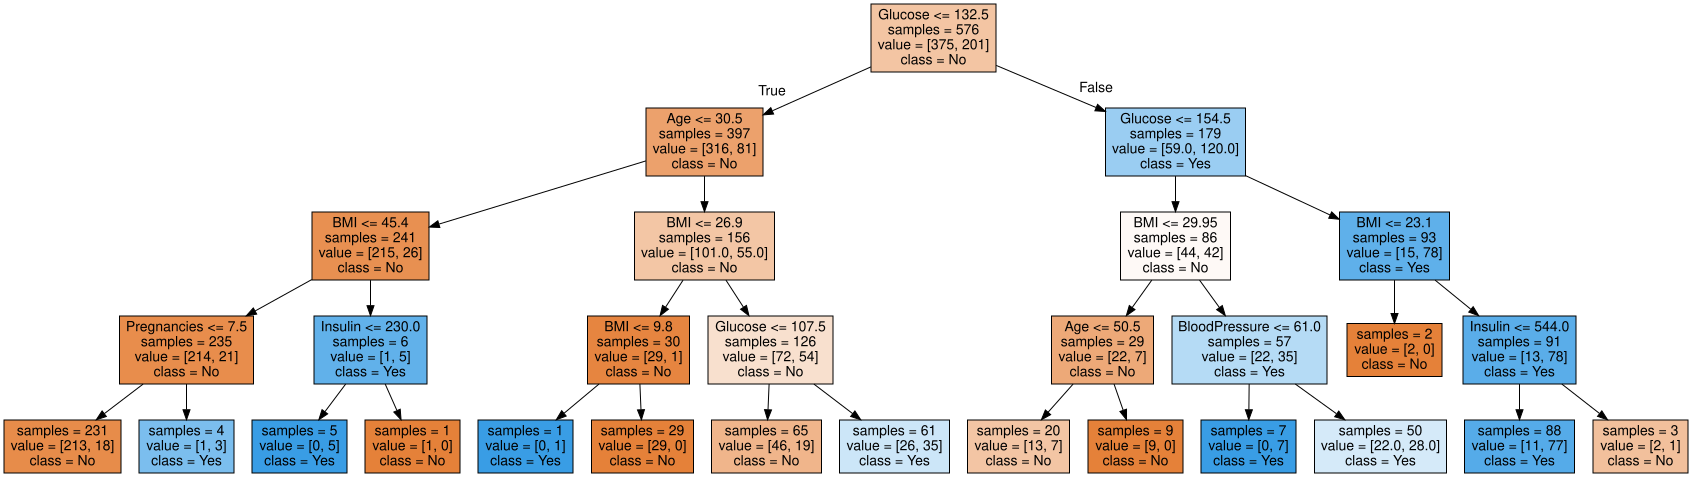

In [9]:
from sklearn.tree import export_graphviz
import graphviz
# Create the random forest graph
export_graphviz(tree, out_file="tree.dot",
                class_names=["No", "Yes"],
                feature_names=x.columns,
                impurity=False,
                filled=True)

with open("tree.dot") as f:
    dot_graph = f.read()

graphviz.Source(dot_graph)